In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('../data/European_Bank.csv')
df = df.drop(columns=['Year'])
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


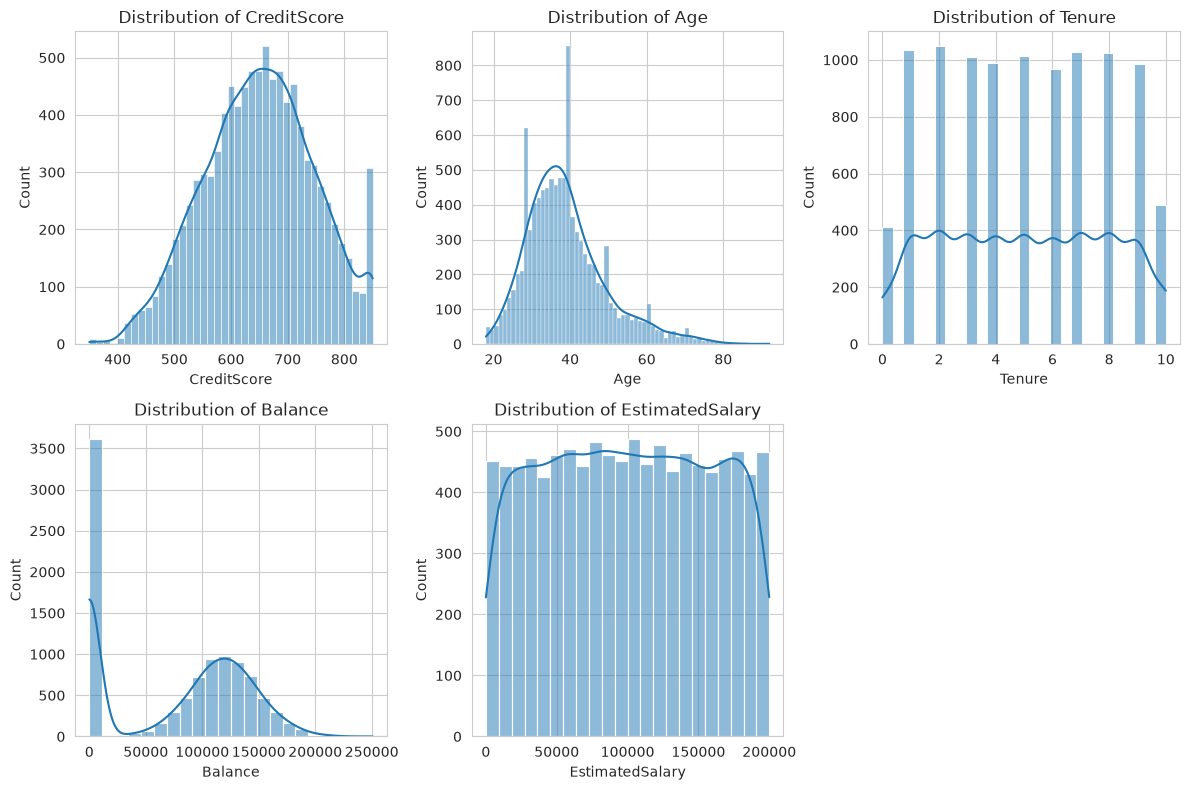

In [2]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(12,8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

fig.delaxes(axes[5])  # remove the unused 6th subplot
plt.tight_layout()
plt.savefig('../outputs/figures/univariate_distributions.png', dpi=200)
plt.show()

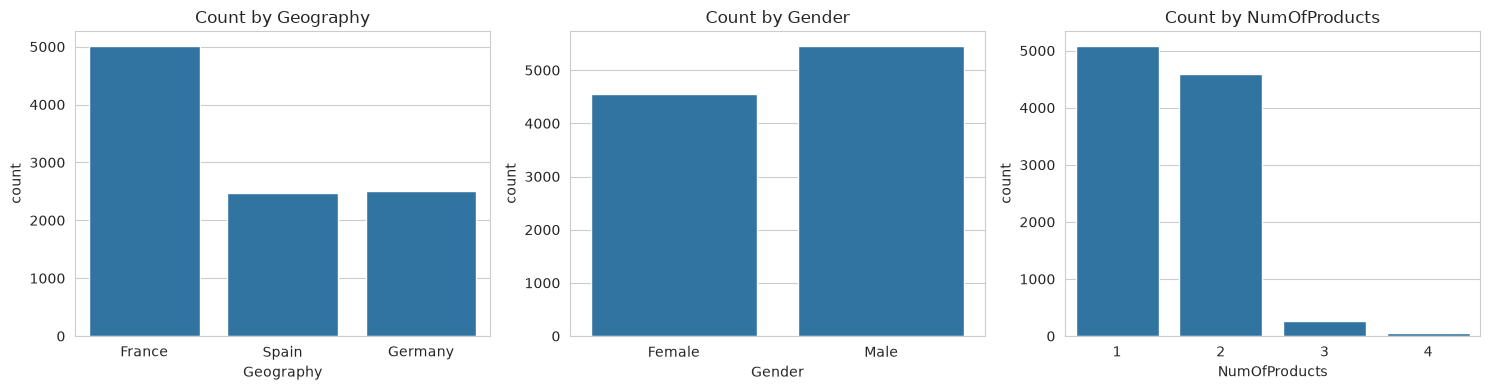

In [3]:
cat_cols = ['Geography', 'Gender', 'NumOfProducts']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Count by {col}')

plt.tight_layout()
plt.savefig('../outputs/figures/categorical_counts.png', dpi=150)
plt.show()

Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64


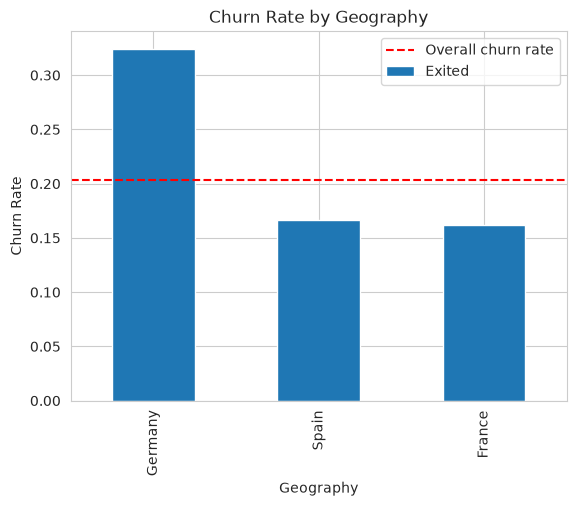

In [4]:
churn_by_geo = df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
print(churn_by_geo)

churn_by_geo.plot(kind='bar', title='Churn Rate by Geography', ylabel='Churn Rate')
plt.axhline(df['Exited'].mean(), color='red', linestyle='--', label='Overall churn rate')
plt.legend()
plt.savefig('../outputs/figures/churn_by_geography.png', dpi=150)
plt.show()

Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64


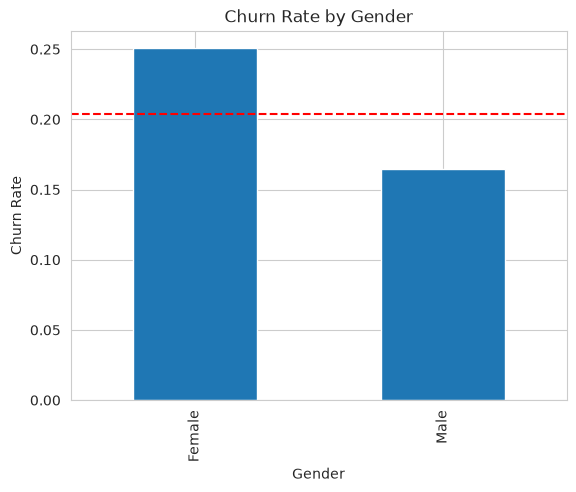

In [5]:
churn_by_gender = df.groupby('Gender')['Exited'].mean().sort_values(ascending=False)
print(churn_by_gender)

churn_by_gender.plot(kind='bar', title='Churn Rate by Gender', ylabel='Churn Rate')
plt.axhline(df['Exited'].mean(), color='red', linestyle='--')
plt.savefig('../outputs/figures/churn_by_gender.png', dpi=150)
plt.show()

AgeBand
18-30    0.075026
31-45    0.157406
46-60    0.511233
61+      0.247845
Name: Exited, dtype: float64


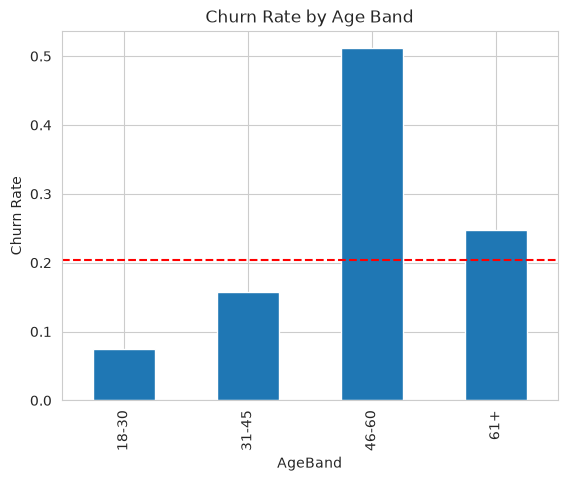

In [6]:
df['AgeBand'] = pd.cut(df['Age'], bins=[18, 30, 45, 60, 92], labels=['18-30', '31-45', '46-60', '61+'])

churn_by_age = df.groupby('AgeBand', observed=True)['Exited'].mean()
print(churn_by_age)

churn_by_age.plot(kind='bar', title='Churn Rate by Age Band', ylabel='Churn Rate')
plt.axhline(df['Exited'].mean(), color='red', linestyle='--')
plt.savefig('../outputs/figures/churn_by_ageband.png', dpi=150)
plt.show()

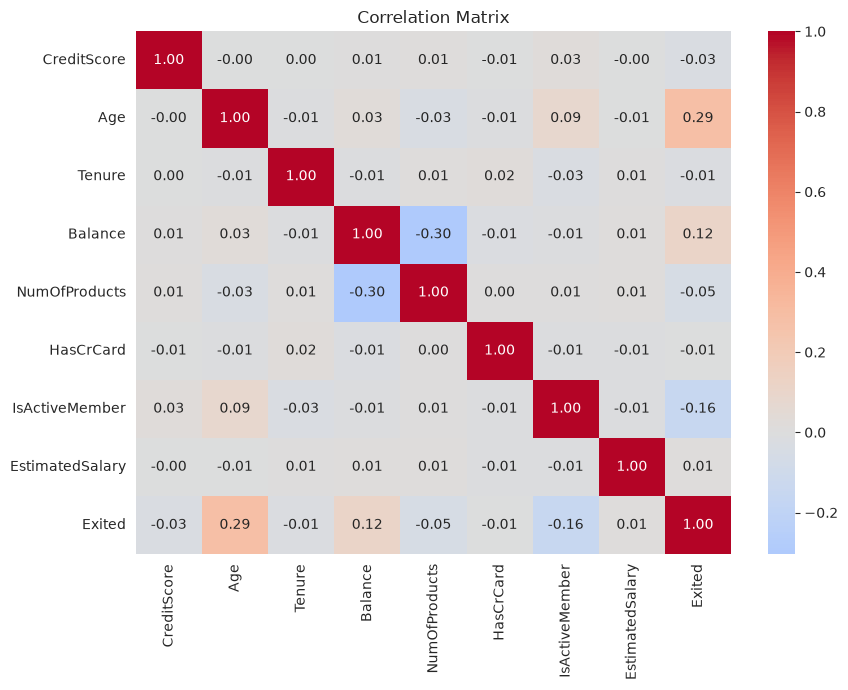

In [7]:
numeric_for_corr = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                     'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

corr = df[numeric_for_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=150)
plt.show()


In [8]:
# Engagement signal
churn_by_active = df.groupby('IsActiveMember')['Exited'].mean()
print("Churn by IsActiveMember:\n", churn_by_active)

# Wealth signal — split Balance at median
df['HighBalance'] = (df['Balance'] > df['Balance'].median()).astype(int)
churn_by_balance = df.groupby('HighBalance')['Exited'].mean()
print("\nChurn by HighBalance:\n", churn_by_balance)

# Compare the spread each one creates
active_spread = churn_by_active.max() - churn_by_active.min()
balance_spread = churn_by_balance.max() - churn_by_balance.min()
print(f"\nSpread from engagement: {active_spread:.4f}")
print(f"Spread from balance: {balance_spread:.4f}")

Churn by IsActiveMember:
 IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

Churn by HighBalance:
 HighBalance
0    0.1576
1    0.2498
Name: Exited, dtype: float64

Spread from engagement: 0.1258
Spread from balance: 0.0922


## EDA Summary

- Geography: Germany shows the highest churn rate at 32.4%, well above the 20.37% baseline. Spain (16.7%) and France (16.2%) sit below baseline.
- Gender: Female customers churn at 25.1% vs Male at 16.5% — a meaningful gap.
- Age: churn rises sharply through middle age, peaking at 51.1% in the 46-60 band, then drops to 24.8% for 61+. The 18-30 band is lowest at 7.5%.
- Correlation: Age has the strongest correlation with Exited (+0.29), followed by IsActiveMember (-0.16) and Balance (+0.12). NumOfProducts, CreditScore, Tenure, HasCrCard, and EstimatedSalary are all weak (|r| < 0.05).
- Engagement vs Balance: IsActiveMember produces a churn spread of 0.126 (inactive: 26.9% vs active: 14.3%), while high/low Balance produces a smaller spread of 0.092 (high balance: 25.0% vs low balance: 15.8%). This supports the hypothesis that engagement is a stronger churn driver than balance alone — though neither comes close to Age's effect.